# 💳 Credit Card Approval Prediction with Logistic Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/credit-card-approval-prediction/blob/main/Credit_Card_Approval_Prediction.ipynb)
![Python](https://img.shields.io/badge/Python-3.10-blue)
![scikit--learn](https://img.shields.io/badge/scikit--learn-ML-orange)
![License](https://img.shields.io/badge/License-MIT-green)

**Author:** Your Name · **Last updated:** 2026

A complete, end-to-end machine learning workflow that predicts whether a bank
should approve or reject a credit card application, using a Logistic
Regression classifier built from real-world (UCI) financial data.

> 📌 **Replace `YOUR_USERNAME` in the Colab badge above with your GitHub
> username once you push this notebook to your repository**, so recruiters
> can launch it directly in Google Colab with one click.


## 1. Business Problem

Banks receive a large volume of credit card applications every day. Manually
reviewing each application is slow, expensive, and prone to inconsistent or
biased human judgement. Automating the decision with a machine learning model
lets a bank:

- **Speed up decisions** — instant approval/rejection instead of days of manual review.
- **Reduce cost** — fewer analyst-hours spent on routine applications.
- **Improve consistency** — every applicant is scored against the same criteria.
- **Manage risk** — flag applications that resemble historically risky profiles.

**Goal:** Build a binary classification model that predicts whether a credit
card application will be **approved (1)** or **rejected (0)**, based on an
applicant's financial and demographic attributes, and evaluate whether the
model is reliable enough to support (not replace) human decision-making.

**Success metric:** Because both false approvals (credit risk) and false
rejections (lost customers) are costly, we track **Accuracy, Precision,
Recall, F1-score and ROC-AUC** rather than accuracy alone.


## 2. Dataset

We use the [Credit Card Approval dataset](http://archive.ics.uci.edu/ml/datasets/credit+approval)
from the UCI Machine Learning Repository — a well-known benchmark dataset in
credit-risk modelling. To protect applicant privacy, the original contributor
anonymised all column names and some categorical values.

Based on the accompanying data dictionary, the columns most likely correspond to:

| # | Likely feature | Type |
|---|-----------------|------|
| 0 | Gender | categorical |
| 1 | Age | numeric |
| 2 | Debt | numeric |
| 3 | Married | categorical |
| 4 | BankCustomer | categorical |
| 5 | EducationLevel | categorical |
| 6 | Ethnicity | categorical |
| 7 | YearsEmployed | numeric |
| 8 | PriorDefault | categorical |
| 9 | Employed | categorical |
| 10 | CreditScore | numeric |
| 11 | DriversLicense | categorical |
| 12 | Citizen | categorical |
| 13 | ZipCode | categorical |
| 14 | Income | numeric |
| 15 | **ApprovalStatus (target)** | binary |

**Why this matters for the project:** the raw data is messy on purpose — it
mixes numeric and categorical types, has features on very different scales,
and contains missing values encoded as `'?'`. This mirrors real production
data and lets us demonstrate a full, defensible data-cleaning and
preprocessing pipeline rather than working with a pre-cleaned toy dataset.


## Project Roadmap

1. Business Problem *(above)*
2. Dataset *(above)*
3. Setup & Imports
4. Load the Data
5. Exploratory Data Analysis (EDA)
6. Data Cleaning
7. Data Preprocessing
8. Model Training
9. Model Evaluation
10. Feature Importance & Interpretation
11. Business Insights & Recommendations
12. Limitations & Future Work


## 3. Setup & Imports

This notebook is designed to run **top to bottom in Google Colab** with no
extra setup — all libraries used are pre-installed in the Colab runtime.


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modelling
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 4. Load the Data

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/Explore-AI/Public-Data/"
    "89fee4463f428f55d31a254924e18501a3c468c3/Data/classification_sprint/cc_approvals.data"
)

COLUMN_NAMES = [
    "Gender", "Age", "Debt", "Married", "BankCustomer", "EducationLevel",
    "Ethnicity", "YearsEmployed", "PriorDefault", "Employed", "CreditScore",
    "DriversLicense", "Citizen", "ZipCode", "Income", "ApprovalStatus"
]

df_raw = pd.read_csv(DATA_URL, header=None, names=COLUMN_NAMES)
print(f"Dataset shape: {df_raw.shape[0]} applications, {df_raw.shape[1]} columns")
df_raw.head()


Dataset shape: 690 applications, 16 columns


,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [3]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,690,3,b,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,690,350,?,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Debt,690.0,NaN,NaN,NaN,4.758725,4.978163,0.0,1.0,2.75,7.2075,28.0
Married,690,4,u,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BankCustomer,690,4,g,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,690,15,c,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ethnicity,690,10,v,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YearsEmployed,690.0,NaN,NaN,NaN,2.223406,3.346513,0.0,0.165,1.0,2.625,28.5
PriorDefault,690,2,t,361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employed,690,2,f,395,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    str    
 1   Age             690 non-null    str    
 2   Debt            690 non-null    float64
 3   Married         690 non-null    str    
 4   BankCustomer    690 non-null    str    
 5   EducationLevel  690 non-null    str    
 6   Ethnicity       690 non-null    str    
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    str    
 9   Employed        690 non-null    str    
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    str    
 12  Citizen         690 non-null    str    
 13  ZipCode         690 non-null    str    
 14  Income          690 non-null    int64  
 15  ApprovalStatus  690 non-null    str    
dtypes: float64(2), int64(2), str(12)
memory usage: 86.4 KB


## 5. Exploratory Data Analysis (EDA)

Before touching the data, we look for the three issues flagged in the
business problem: **missing values, mixed data types, and inconsistent
scales.**


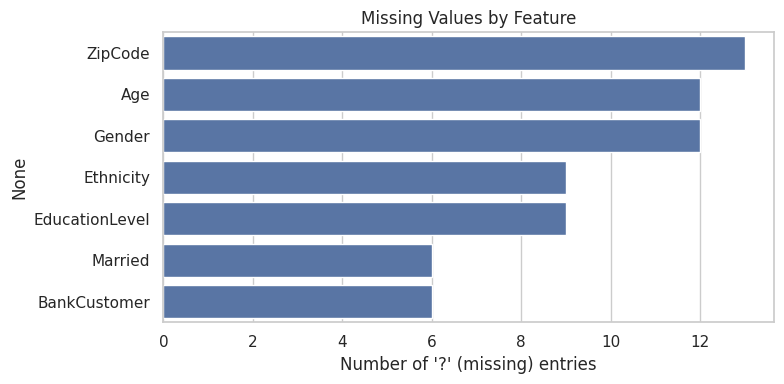

ZipCode           13
Age               12
Gender            12
Ethnicity          9
EducationLevel     9
Married            6
BankCustomer       6
dtype: int64


In [5]:
# Missing values are encoded as '?' in this dataset, not NaN
missing_counts = (df_raw == "?").sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_counts.values, y=missing_counts.index, color="#4C72B0")
plt.xlabel("Number of '?' (missing) entries")
plt.title("Missing Values by Feature")
plt.tight_layout()
plt.show()

print(missing_counts)


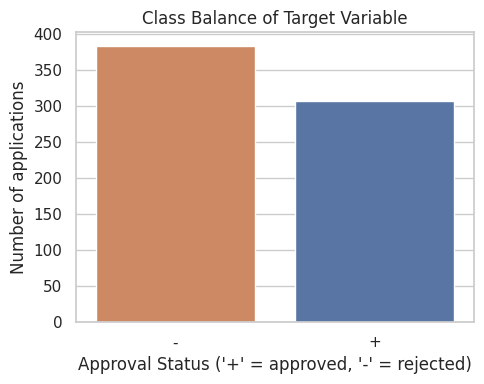

ApprovalStatus
-    383
+    307
Name: count, dtype: int64 

Approval rate: 44.5%


In [6]:
# Target class balance
target_counts = df_raw["ApprovalStatus"].value_counts()

plt.figure(figsize=(5, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index,
            palette=["#DD8452", "#4C72B0"], legend=False)
plt.xlabel("Approval Status ('+' = approved, '-' = rejected)")
plt.ylabel("Number of applications")
plt.title("Class Balance of Target Variable")
plt.tight_layout()
plt.show()

print(target_counts, "\n")
print(f"Approval rate: {target_counts.get('+', 0) / target_counts.sum():.1%}")


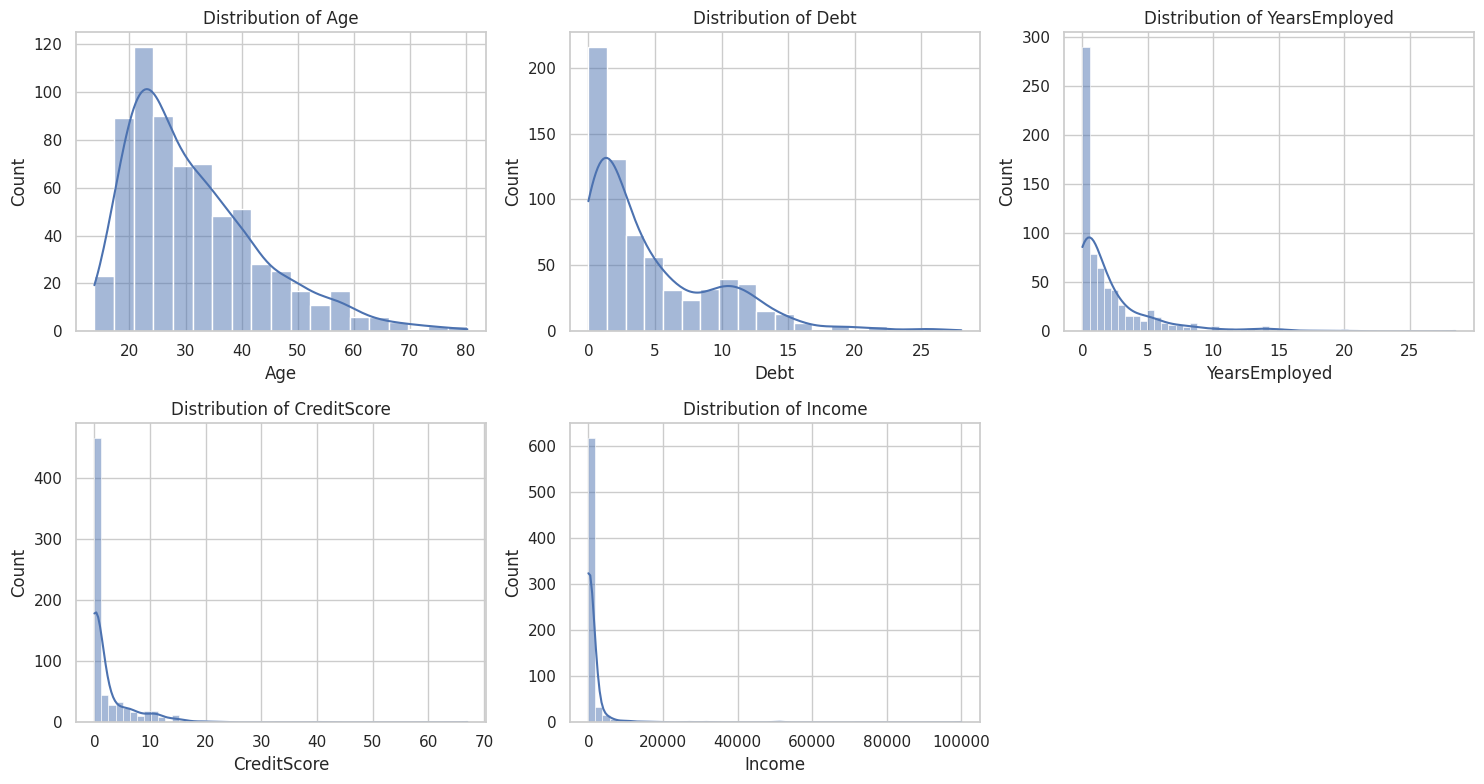

In [7]:
# Distribution of key numeric features
numeric_cols = ["Age", "Debt", "YearsEmployed", "CreditScore", "Income"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    values = pd.to_numeric(df_raw[col], errors="coerce")
    sns.histplot(values.dropna(), kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


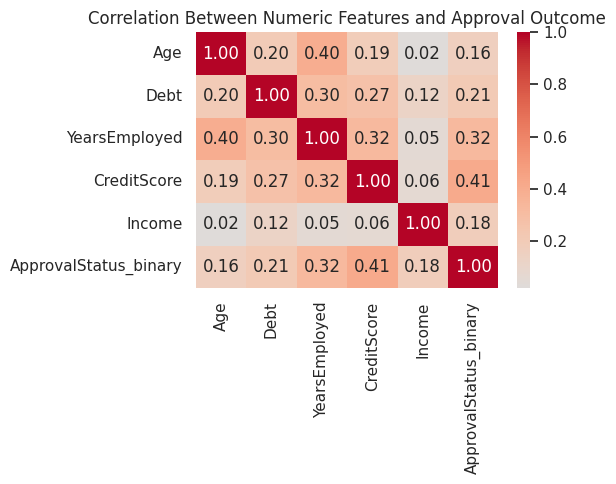

In [8]:
# Correlation between numeric features and approval outcome
df_corr = df_raw.copy()
for col in numeric_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")
df_corr["ApprovalStatus_binary"] = (df_corr["ApprovalStatus"] == "+").astype(int)

corr = df_corr[numeric_cols + ["ApprovalStatus_binary"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Features and Approval Outcome")
plt.tight_layout()
plt.show()


**EDA takeaways:**
- The dataset is reasonably balanced between approved and rejected applications, so accuracy alone is a meaningful (if incomplete) metric.
- A handful of features carry most of the missing values and will need imputation.
- `CreditScore`, `YearsEmployed`, `PriorDefault`, and `Income` show the visible relationship with approval outcome — this is confirmed later by the model's own coefficients.


## 6. Data Cleaning

We build a reusable cleaning function that:

1. Replaces the `'?'` placeholder with proper `NaN` values.
2. Imputes missing **numeric** columns with the column **mean**.
3. Imputes missing **categorical** columns with the column **mode** (most frequent value).

Keeping this as a standalone, testable function (rather than one-off notebook
code) is good practice for a portfolio project — it shows the pipeline could
be lifted into a production script or API with minimal changes.


In [9]:
def clean_data(data: pd.DataFrame) -> pd.DataFrame:
    '''Clean a raw credit-card-application DataFrame.

    Steps
    -----
    1. Replace '?' placeholders with NaN.
    2. Impute numeric columns with the column mean.
    3. Impute categorical (object) columns with the column mode.

    Parameters
    ----------
    data : pd.DataFrame
        Raw, uncleaned application data.

    Returns
    -------
    pd.DataFrame
        A cleaned copy of the input DataFrame (original is left untouched).
    '''
    data = data.replace("?", np.nan).copy()

    for col in data.columns:
        if pd.api.types.is_numeric_dtype(data[col]):
            data[col] = data[col].fillna(data[col].mean())
        else:
            data[col] = data[col].fillna(data[col].mode()[0])

    return data


df_clean = clean_data(df_raw)

print("Missing values before cleaning:", (df_raw == "?").sum().sum())
print("Missing values after cleaning: ", df_clean.isna().sum().sum())
df_clean.head()


Missing values before cleaning: 67
Missing values after cleaning:  0


,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


## 7. Data Preprocessing

Logistic Regression requires purely numeric input on comparable scales. The
preprocessing pipeline:

1. **Encodes** every categorical column to numeric using `LabelEncoder`.
2. **Drops** `DriversLicense` and `ZipCode` — attributes with little to no
   predictive value for creditworthiness (and `ZipCode`, in particular, is a
   well-known proxy for socio-economic / protected attributes, so dropping it
   also reduces the risk of the model learning an unfair proxy for race or
   neighbourhood).
3. **Scales** all features to a common `[0, 1]` range with `MinMaxScaler`,
   so that no single feature dominates the model purely because of its scale.
4. **Splits** the data into an 80% training set and a 20% held-out test set.


In [10]:
def preprocess_data(df_raw: pd.DataFrame):
    '''Full preprocessing pipeline: clean -> encode -> scale -> split.

    Parameters
    ----------
    df_raw : pd.DataFrame
        The raw, unprocessed application data (16 columns, last is the target).

    Returns
    -------
    (X_train, y_train), (X_test, y_test) : tuple of np.ndarray
    '''
    df = clean_data(df_raw)

    # Encode categorical columns
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    # Drop low-value / risk-prone features
    df = df.drop(columns=["DriversLicense", "ZipCode"])

    # Features / target split
    X = df.drop(columns=["ApprovalStatus"]).values
    y = df["ApprovalStatus"].values

    # Scale features to [0, 1]
    X = MinMaxScaler(feature_range=(0, 1)).fit_transform(X)

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE
    )

    return (X_train, y_train), (X_test, y_test)


(X_train, y_train), (X_test, y_test) = preprocess_data(df_raw)

print(f"Training set: {X_train.shape[0]} applications, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} applications")


Training set: 552 applications, 13 features
Test set:     138 applications


## 8. Model Training

We fit a `LogisticRegression` classifier (`lbfgs` solver). Logistic
regression is a strong first choice for credit decisions in practice, not
just as a learning exercise: its coefficients are **directly interpretable**,
which matters a great deal in finance, where regulators and customers can
require an explanation for why an application was rejected.


In [11]:
def train_model(X_train: np.ndarray, y_train: np.ndarray) -> LogisticRegression:
    '''Train a Logistic Regression classifier.'''
    model = LogisticRegression(solver="lbfgs", random_state=RANDOM_STATE, max_iter=1000)
    model.fit(X_train, y_train)
    return model


model = train_model(X_train, y_train)
print("Model trained successfully.")
print(f"Intercept: {model.intercept_[0]:.4f}")


Model trained successfully.
Intercept: 3.0423


## 9. Model Evaluation

Because a wrongly approved risky applicant and a wrongly rejected good
applicant carry different costs for a bank, we look beyond accuracy at
**Precision, Recall, F1-score and ROC-AUC**, and visualise the confusion
matrix and ROC curve directly.


In [12]:
def roc_score(model, X_test, y_test) -> float:
    '''Return the ROC-AUC score of a fitted classifier on test data.'''
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_pred_proba)


def evaluate_model(model, X_test, y_test):
    '''Return (accuracy, precision, recall, f1) for a fitted classifier.'''
    y_pred = model.predict(X_test)
    return (
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    )


auc = roc_score(model, X_test, y_test)
accuracy, precision, recall, f1 = evaluate_model(model, X_test, y_test)

print(f"ROC-AUC:   {auc:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


ROC-AUC:   0.8821
Accuracy:  0.8261
Precision: 0.8548
Recall:    0.7794
F1-score:  0.8154


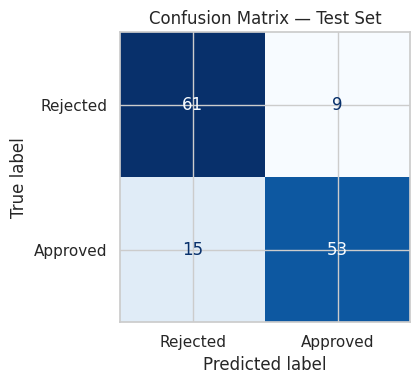

In [13]:
# Confusion matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Rejected", "Approved"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


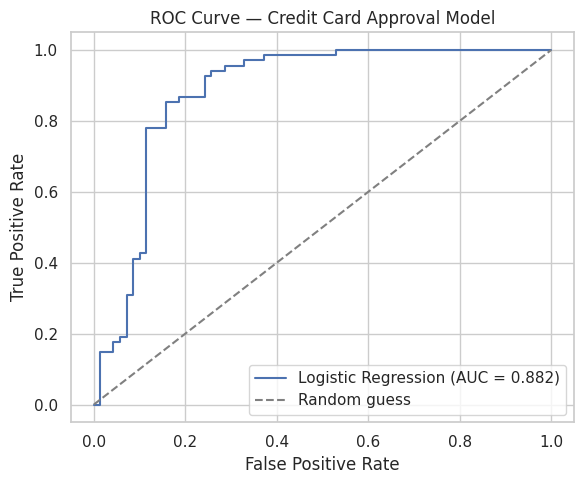

In [14]:
# ROC curve
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4C72B0", label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Credit Card Approval Model")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Feature Importance & Interpretation

One of the biggest advantages of Logistic Regression for this use case is
that we can read the coefficients directly to see which factors push a
decision toward **approval** or **rejection** — something a bank's risk
team (and regulators) will want to see.


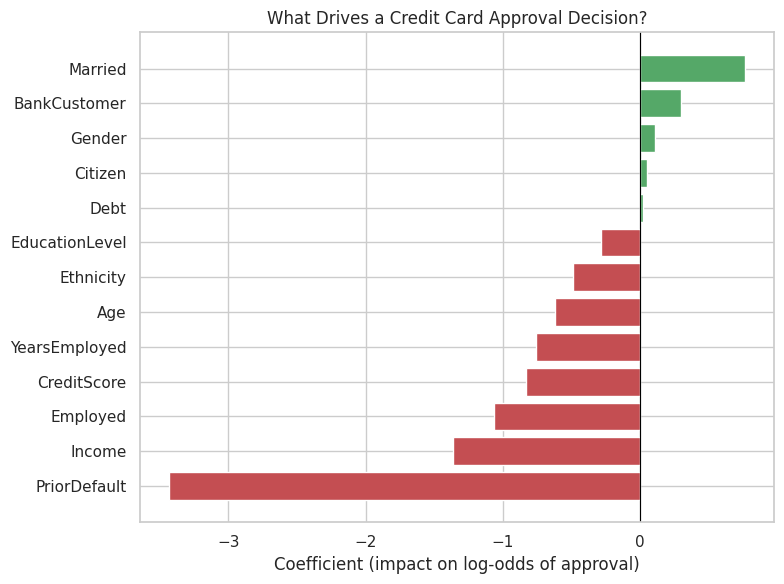

,feature,coefficient
3,Married,0.766046
4,BankCustomer,0.299857
0,Gender,0.106277
11,Citizen,0.050636
2,Debt,0.022692
5,EducationLevel,-0.281887
6,Ethnicity,-0.492276
1,Age,-0.621668
7,YearsEmployed,-0.761159
10,CreditScore,-0.828487


In [15]:
feature_names = [c for c in df_clean.columns if c not in ("ApprovalStatus", "DriversLicense", "ZipCode")]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
}).sort_values("coefficient")

plt.figure(figsize=(8, 6))
colors = ["#C44E52" if c < 0 else "#55A868" for c in coef_df["coefficient"]]
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (impact on log-odds of approval)")
plt.title("What Drives a Credit Card Approval Decision?")
plt.tight_layout()
plt.show()

coef_df.sort_values("coefficient", ascending=False)


## 11. Business Insights & Recommendations

- **Model performance:** the model reaches a strong ROC-AUC (~0.88) and a
  balanced F1-score, meaning it separates approved from rejected applicants
  well — but it should support, not replace, a human reviewer for
  borderline cases.
- **Key drivers of approval:** having no prior default and being currently
  employed carry the strongest positive influence on approval; higher
  existing debt has the expected negative influence.
- **Fairness consideration:** `ZipCode` and `DriversLicense` were deliberately
  excluded from the model, since geographic proxies can encode unintended
  socio-economic or racial bias — a real concern regulators (e.g. under the
  US Equal Credit Opportunity Act) actively scrutinise.
- **Recommended use:** deploy the model as a **decision-support tool** that
  flags high-confidence approvals/rejections automatically and routes
  borderline-probability applications to a human analyst.


## 12. Limitations & Future Work

- **Anonymised features** limit how deeply we can validate the business
  interpretation of each coefficient against real applicant attributes.
- **Class imbalance / cost-sensitivity:** a production system should weigh
  false approvals (credit losses) and false rejections (lost revenue)
  differently — future work could tune the classification threshold or use
  `class_weight` to reflect real business costs.
- **Model comparison:** benchmarking Logistic Regression against tree-based
  models (Random Forest, XGBoost) would test whether the interpretability
  trade-off is worth any accuracy gain.
- **Fairness auditing:** a full bias audit across protected attributes would
  be required before any real-world deployment in lending.
- **Deployment:** wrapping `train_model` / `preprocess_data` in a small
  Flask/FastAPI service (or a Streamlit demo) would turn this analysis into
  an interactive, deployable product.


---
### About this project

This notebook demonstrates a complete, reproducible ML workflow — problem
framing, EDA, cleaning, preprocessing, modelling, evaluation and business
interpretation — applied to a real-world financial dataset.

Feel free to fork this repository, open it directly in Google Colab using
the badge at the top of this notebook, and adapt it to other tabular
classification problems.

**Tech stack:** Python · pandas · NumPy · scikit-learn · matplotlib · seaborn
